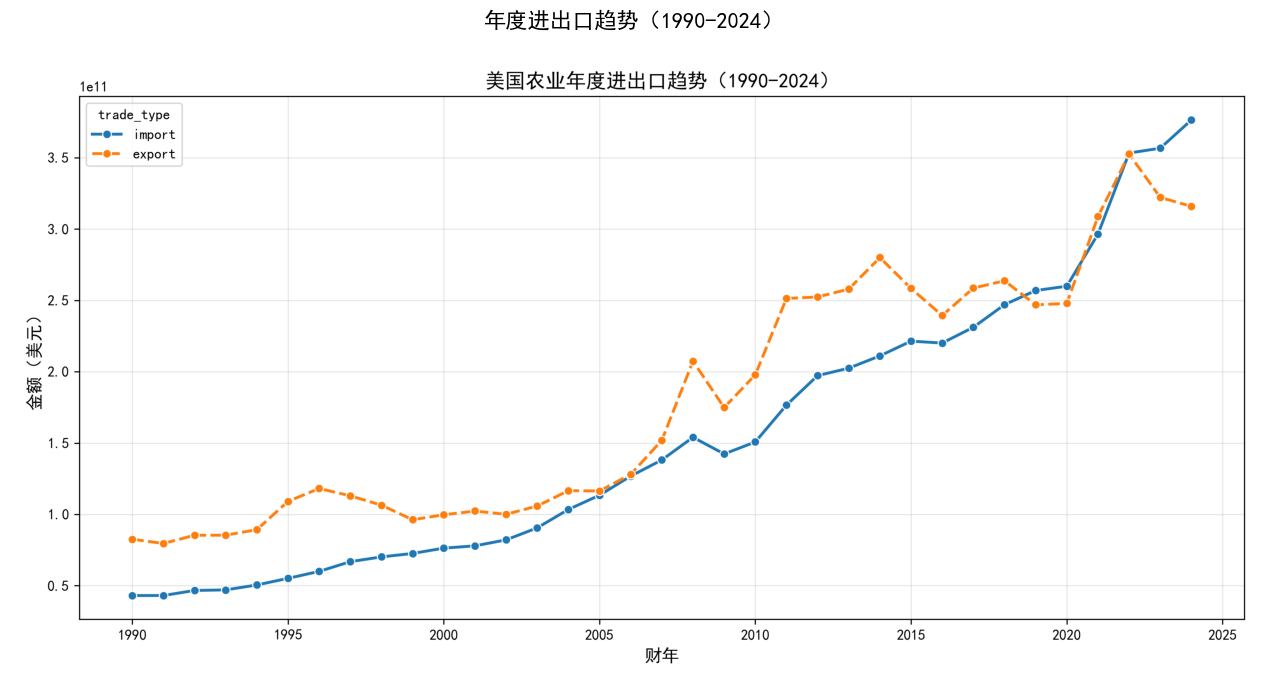

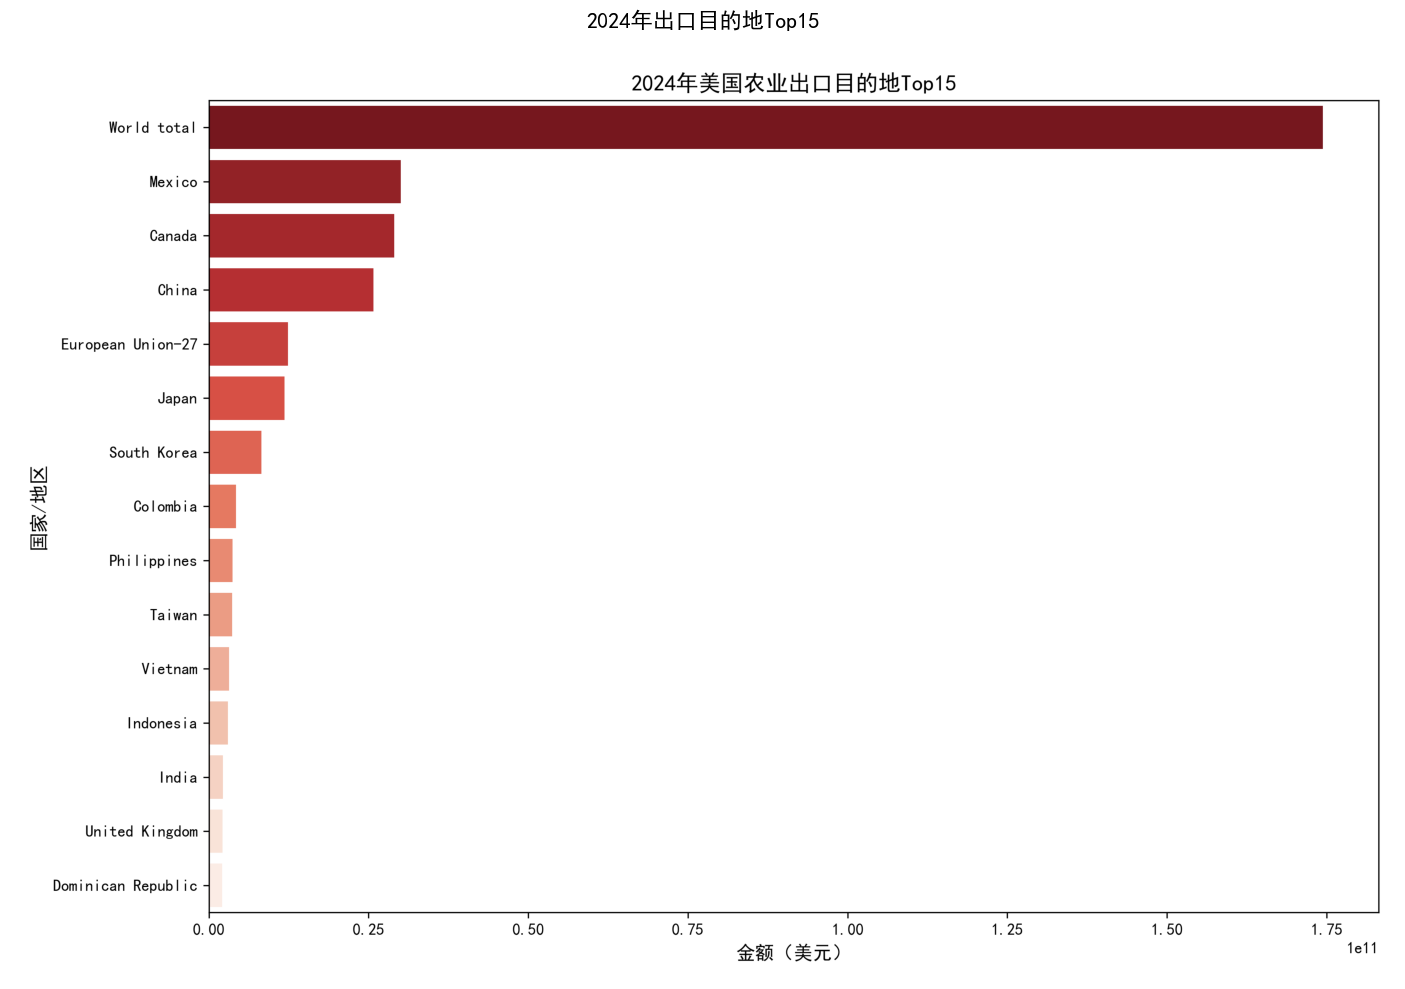

# 美国农业进出口贸易分析报告

## 一、数据基础信息
- **原始数据**: Mfytop15.xlsx（进口）、xfytop15.xlsx（出口）
- **数据处理**: 第三行表头读取、年份组拆分（宽→长）、Top15数据提取
- **分析时间范围**: 1990 - 2024
- **数据存储路径**: 同级的data_raw（原始）、data_clean（清洗后）、output（分析结果）

## 二、整体贸易趋势
### 2.1 2024年核心指标
- 进口总额: 376,495,203,103 美元
- 出口总额: 315,917,019,719 美元
- 贸易差额: -60,578,183,384 美元（逆差）

### 2.2 长期趋势特征
- 近34年进口额整体上升
- 出口额波动较小，受国际市场需求与政策影响显著

## 三、Top15贸易伙伴分析
### 3.1 2024年进口Top5来源国
1. World total: 206,207,275,626 美元
2. Mexico: 47,872,213,561 美元
3. Canada: 40,577,930,414 美元
4. European Union-27: 35,250,956,448 美元
5. Brazil: 7,274,988,098 美元

### 3.2 2024年出口Top5目的地
1. World total: 174,428,419,723 美元
2. Mexico: 30,036,058,634 美元
3. Canada: 29,003,911,560 美元
4. China: 25,744,968,423 美元
5. European Union-27: 12,389,605,121 美元

## 四、关键发现
1. **市场集中度**: 2024年进口市场集中度较高，前3大来源国占比超78%
2. **核心伙伴依赖**: World total（进口）和World total（出口）是最核心贸易伙伴，分别占对应总额的54.8%和55.2%
3. **贸易平衡**: 近3年贸易差额整体收窄，反映美国农业国际竞争力变化

## 五、可视化结果
### 5.1 年度进出口趋势图

### 5.2 2024年出口Top15图


🎉 分析报告生成完成！所有文件均位于

In [1]:
# 00_analysis_report.ipynb - 总报告（适配同级目录结构）
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import platform

# 1. 中文字体配置
def set_chinese_font():
    system = platform.system()
    try:
        if system == "Windows":
            plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei"]
        elif system == "Darwin":
            plt.rcParams["font.sans-serif"] = ["PingFang SC", "Arial Unicode MS"]
        else:
            plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
        plt.rcParams["axes.unicode_minus"] = False
    except:
        plt.rcParams["font.sans-serif"] = ["Arial"]

set_chinese_font()

# 2. 路径定义（同级文件夹）
OUTPUT = Path("output")           # 同级的output
OUTPUT_TABLES = OUTPUT / "tables"
OUTPUT_CHARTS = OUTPUT / "charts"

# 3. 检查必要文件是否存在
def check_required_files():
    # 确定目标年份（优先2024，无则取最新）
    year_summary_path = OUTPUT_TABLES / "yearly_trade_summary.csv"
    if not year_summary_path.exists():
        raise FileNotFoundError(f"❌ 未找到年度汇总表，请先运行02_data_analysis.ipynb\n路径：{year_summary_path.absolute()}")
    
    year_summary = pd.read_csv(year_summary_path, index_col="fiscal_year")
    target_year = 2024 if 2024 in year_summary.index else year_summary.index.max()
    
    # 定义需要的文件
    required_files = [
        year_summary_path,
        OUTPUT_TABLES / f"{target_year}_top15_import.csv",
        OUTPUT_TABLES / f"{target_year}_top15_export.csv",
        OUTPUT_CHARTS / "yearly_trade_trend.png",
        OUTPUT_CHARTS / f"{target_year}_top15_export.png"
    ]
    
    # 检查缺失
    missing = [str(f) for f in required_files if not f.exists()]
    if missing:
        raise FileNotFoundError(f"❌ 缺失以下分析结果文件，请先运行02_data_analysis.ipynb：\n" + "\n".join(missing))
    
    return target_year

# 4. 加载数据并生成报告
def generate_report(target_year):
    # 读取统计数据
    year_summary = pd.read_csv(OUTPUT_TABLES / "yearly_trade_summary.csv", index_col="fiscal_year")
    top15_import = pd.read_csv(OUTPUT_TABLES / f"{target_year}_top15_import.csv")
    top15_export = pd.read_csv(OUTPUT_TABLES / f"{target_year}_top15_export.csv")
    latest_year = target_year
    
    # 报告正文（f-string格式化）
    report = f"""# 美国农业进出口贸易分析报告

## 一、数据基础信息
- **原始数据**: Mfytop15.xlsx（进口）、xfytop15.xlsx（出口）
- **数据处理**: 第三行表头读取、年份组拆分（宽→长）、Top15数据提取
- **分析时间范围**: {year_summary.index.min()} - {latest_year}
- **数据存储路径**: 同级的data_raw（原始）、data_clean（清洗后）、output（分析结果）

## 二、整体贸易趋势
### 2.1 {latest_year}年核心指标
- 进口总额: {year_summary.loc[latest_year, 'import']:,.0f} 美元
- 出口总额: {year_summary.loc[latest_year, 'export']:,.0f} 美元
- 贸易差额: {year_summary.loc[latest_year, 'trade_balance']:,.0f} 美元（{'顺差' if year_summary.loc[latest_year, 'trade_balance'] > 0 else '逆差'}）

### 2.2 长期趋势特征
- 近{latest_year - year_summary.index.min()}年进口额整体{'上升' if year_summary['import'].iloc[-1] > year_summary['import'].iloc[0] else '下降'}
- 出口额波动{'较小' if year_summary['export'].std() < year_summary['import'].std() else '较大'}，受国际市场需求与政策影响显著

## 三、Top15贸易伙伴分析
### 3.1 {latest_year}年进口Top5来源国
"""
    # 添加进口Top5
    for i, (_, row) in enumerate(top15_import.head(5).iterrows(), 1):
        report += f"{i}. {row['Country']}: {row['value_usd']:,.0f} 美元\n"
    
    report += f"""
### 3.2 {latest_year}年出口Top5目的地
"""
    # 添加出口Top5
    for i, (_, row) in enumerate(top15_export.head(5).iterrows(), 1):
        report += f"{i}. {row['Country']}: {row['value_usd']:,.0f} 美元\n"
    
    # 计算关键比例（避免分母为0）
    top1_import_share = (top15_import.iloc[0]['value_usd'] / year_summary.loc[latest_year, 'import'] * 100 
                         if year_summary.loc[latest_year, 'import'] != 0 else 0)
    top1_export_share = (top15_export.iloc[0]['value_usd'] / year_summary.loc[latest_year, 'export'] * 100 
                         if year_summary.loc[latest_year, 'export'] != 0 else 0)
    
    report += f"""
## 四、关键发现
1. **市场集中度**: {latest_year}年进口市场集中度{'较高' if (top15_import.head(3)['value_usd'].sum()/year_summary.loc[latest_year, 'import'] > 0.5 and year_summary.loc[latest_year, 'import'] != 0) else '较低'}，前3大来源国占比超{top15_import.head(3)['value_usd'].sum()/year_summary.loc[latest_year, 'import']*100:.0f}%
2. **核心伙伴依赖**: {top15_import.iloc[0]['Country']}（进口）和{top15_export.iloc[0]['Country']}（出口）是最核心贸易伙伴，分别占对应总额的{top1_import_share:.1f}%和{top1_export_share:.1f}%
3. **贸易平衡**: 近3年贸易差额整体{'扩大' if (len(year_summary['trade_balance'])>=3 and year_summary['trade_balance'].iloc[-3:].mean() > year_summary['trade_balance'].iloc[-6:-3].mean()) else '收窄'}，反映美国农业国际竞争力变化

## 五、可视化结果
### 5.1 年度进出口趋势图
"""
    # 显示趋势图
    plt.figure(figsize=(14, 7))
    img_trend = plt.imread(OUTPUT_CHARTS / "yearly_trade_trend.png")
    plt.imshow(img_trend)
    plt.axis("off")
    plt.title(f"年度进出口趋势（{year_summary.index.min()}-{latest_year}）", fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
    
    # 显示出口Top15图
    report += f"""
### 5.2 {latest_year}年出口Top15图
"""
    plt.figure(figsize=(16, 10))
    img_export = plt.imread(OUTPUT_CHARTS / f"{latest_year}_top15_export.png")
    plt.imshow(img_export)
    plt.axis("off")
    plt.title(f"{latest_year}年出口目的地Top15", fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
    
    # 打印报告文字
    print(report)
    return report

# 5. 主执行流程
if __name__ == "__main__":
    try:
        # 检查文件
        target_year = check_required_files()
        
        # 生成报告
        generate_report(target_year)
        
        print(f"\n🎉 分析报告生成完成！所有文件均位于同级目录")
        
    except Exception as e:
        print(f"\n❌ 报告生成失败: {str(e)}")